In [60]:
import json
import string

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import pandas as pd
import unidecode
from Levenshtein import ratio
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

True

In [61]:
with open("../data/professores.json", encoding="utf-8") as f:
    professores = json.load(f)


In [62]:
dados = []

for prof in professores:
    nome = prof.get("identificacao", {}).get("nome", "")
    producoes = prof.get("producao_bibliografica", [])

    dados.append(
        {
            "nome": nome,
            "producoes_bibliograficas": producoes,
        }
    )

df = pd.DataFrame(dados)

In [63]:
df


,nome,producoes_bibliograficas
0,Adriana Carla Damasceno,[{'titulo': 'Supporting the choice of the best...
1,Alan Kelon Oliveira de Moraes,[{'titulo': 'A family of test selection criter...
2,Alisson Vasconcelos de Brito,[{'titulo': 'Fault diagnosis in split-system a...
3,Alvaro Francisco de Castro Medeiros,[{'titulo': 'OBJECT-ORIENTED DEVELOPMENT SOFTW...
4,Ana Paula Pintado Wyse,[{'titulo': 'Mathematical modeling of the perf...
...,...,...
62,Valdecir Becker,[{'titulo': 'Avaliação de sistemas de Governo ...
63,Verônica Maria Lima Silva,[{'titulo': 'PREDICCIÓN Y DIAGNÓSTICO DEL ALZH...
64,Vitor Meneghetti Ugulino de Araujo,[{'titulo': 'Bridging the Digital Divide: Unde...
65,Yuri de Almeida Malheiros Barbosa,[{'titulo': 'Assessment of volumetric dense ti...


In [64]:
dados = []

for prof in professores:
    nome = prof.get("identificacao", {}).get("nome", "")
    producoes = prof.get("producao_bibliografica", [])

    for idx, producao in enumerate(producoes, start=1):
        # Extrair ano da produção (ajuste conforme estrutura real)
        ano = producao.get("ano", "0000")

        dados.append({"nome_professor": nome, "ano": ano, "producao": producao})

df_producoes = pd.DataFrame(dados)
df_producoes

,nome_professor,ano,producao
0,Adriana Carla Damasceno,2023,{'titulo': 'Supporting the choice of the best-...
1,Adriana Carla Damasceno,2017,{'titulo': 'Descrevendo o uso dos computadores...
2,Adriana Carla Damasceno,2017,{'titulo': 'Testing real-time systems from com...
3,Adriana Carla Damasceno,2009,{'titulo': 'A Mechanized Strategy for Safe Abs...
4,Adriana Carla Damasceno,None,{'titulo': 'SELECIONANDO MODELOS DE SOFTWARE A...
...,...,...,...
5405,Yuska Paola Costa Aguiar,2015,{'titulo': 'Oficina de Projeto de Interface. 2...
5406,Yuska Paola Costa Aguiar,2008,{'titulo': 'Avaliação de Usabilidade de Produt...
5407,Yuska Paola Costa Aguiar,2008,"{'titulo': 'YP, MEDITE e FASTINTERFACE: Facili..."
5408,Yuska Paola Costa Aguiar,2002,{'titulo': 'Informática Básica. 2002. (Curso d...


In [65]:
#  Contagem de nulos por coluna
print("Nulos por coluna:")
print(df_producoes.isna().sum())


# Mostrar as linhas que têm valor nulo
print("\nLinhas com algum nulo:")
display(df_producoes[df_producoes.isna().any(axis=1)])


Nulos por coluna:
nome_professor      0
ano               220
producao            0
dtype: int64

Linhas com algum nulo:


,nome_professor,ano,producao
4,Adriana Carla Damasceno,None,{'titulo': 'SELECIONANDO MODELOS DE SOFTWARE A...
271,Alvaro Francisco de Castro Medeiros,None,{'titulo': 'OBJECT-ORIENTED DEVELOPMENT SOFTWA...
272,Alvaro Francisco de Castro Medeiros,None,{'titulo': 'CONSOLIDATING CONTROL MODELS IN IE...
273,Alvaro Francisco de Castro Medeiros,None,{'titulo': 'R-CYCLE: A PRACTICAL APPROACH FOR ...
274,Alvaro Francisco de Castro Medeiros,None,{'titulo': 'PROPOSTA DE UM MOLDE MAIS REALISTA...
...,...,...,...
4490,Thaís Gaudencio do Rêgo,None,{'titulo': 'Padrões e Respostas - Tecnologias ...
4491,Thaís Gaudencio do Rêgo,None,{'titulo': 'Uso de Inteligência Artificial na ...
4492,Thaís Gaudencio do Rêgo,None,{'titulo': 'Genômica e Bioinformática: Importâ...
4964,Valdecir Becker,None,{'titulo': 'Progressos da TV digital brasileir...


In [66]:
STOPWORDS = set(stopwords.words("portuguese") + stopwords.words("english"))


def limpar_titulo(texto_completo):
    if not isinstance(texto_completo, str):
        return ""

    titulo_base = texto_completo.split(". ")[0]
    titulo_limpo = unidecode.unidecode(titulo_base.lower())
    titulo_limpo = titulo_limpo.translate(str.maketrans("", "", string.punctuation))

    palavras = [p for p in titulo_limpo.split() if p and p not in STOPWORDS]

    return " ".join(palavras)


df_producoes["titulo_limpo"] = df_producoes["producao"].apply(
    lambda x: limpar_titulo(x.get("titulo", ""))
)

df_producoes["duas_primeiras_letras"] = df_producoes["titulo_limpo"].str[:2]

In [67]:
df_producoes

,nome_professor,ano,producao,titulo_limpo,duas_primeiras_letras
0,Adriana Carla Damasceno,2023,{'titulo': 'Supporting the choice of the best-...,supporting choice bestfit agile model using fi...,su
1,Adriana Carla Damasceno,2017,{'titulo': 'Descrevendo o uso dos computadores...,descrevendo uso computadores escolas publicas ...,de
2,Adriana Carla Damasceno,2017,{'titulo': 'Testing real-time systems from com...,testing realtime systems compositional symboli...,te
3,Adriana Carla Damasceno,2009,{'titulo': 'A Mechanized Strategy for Safe Abs...,mechanized strategy safe abstraction csp speci...,me
4,Adriana Carla Damasceno,None,{'titulo': 'SELECIONANDO MODELOS DE SOFTWARE A...,selecionando modelos software automaticamente ...,se
...,...,...,...,...,...
5405,Yuska Paola Costa Aguiar,2015,{'titulo': 'Oficina de Projeto de Interface. 2...,oficina projeto interface,of
5406,Yuska Paola Costa Aguiar,2008,{'titulo': 'Avaliação de Usabilidade de Produt...,avaliacao usabilidade produtos hardwaresoftware,av
5407,Yuska Paola Costa Aguiar,2008,"{'titulo': 'YP, MEDITE e FASTINTERFACE: Facili...",yp medite fastinterface facilitando processo e...,yp
5408,Yuska Paola Costa Aguiar,2002,{'titulo': 'Informática Básica. 2002. (Curso d...,informatica basica,in


In [68]:
# Verificar duplicatas por professor, título limpo e ano
duplicatas_titulo = df_producoes[
    df_producoes.duplicated(
        subset=["nome_professor", "titulo_limpo", "ano"], keep=False
    )
]

duplicatas_titulo

,nome_professor,ano,producao,titulo_limpo,duas_primeiras_letras
3,Adriana Carla Damasceno,2009,{'titulo': 'A Mechanized Strategy for Safe Abs...,mechanized strategy safe abstraction csp speci...,me
11,Adriana Carla Damasceno,2014,{'titulo': 'Uso dos computadores nas escolas p...,uso computadores escolas publicas alto sertao ...,us
12,Adriana Carla Damasceno,2012,{'titulo': 'Automatic Test Generation of Compo...,automatic test generation compositional realti...,au
13,Adriana Carla Damasceno,2011,{'titulo': 'Inclusão Digital na cidade de Pomb...,inclusao digital cidade pombal,in
19,Adriana Carla Damasceno,2011,{'titulo': 'Inclusão Digital na cidade de Pomb...,inclusao digital cidade pombal,in
...,...,...,...,...,...
5381,Yuska Paola Costa Aguiar,2010,{'titulo': 'Programming a user model with data...,programming user model data gathered user profile,pr
5382,Yuska Paola Costa Aguiar,2010,{'titulo': 'Experimental Protocol for accessib...,experimental protocol accessibility evaluation,ex
5387,Yuska Paola Costa Aguiar,2007,"{'titulo': 'SMILE: ferramenta para geração, ed...",smile ferramenta geracao edicao simulacao esbo...,sm
5388,Yuska Paola Costa Aguiar,2007,"{'titulo': 'SMILE: ferramenta para geração, ed...",smile ferramenta geracao edicao simulacao esbo...,sm


In [69]:
# Remove duplicatas onde o mesmo professor tem o mesmo título limpo no mesmo ano
df_producoes = df_producoes.drop_duplicates(
    subset=["nome_professor", "titulo_limpo", "ano"]
)

In [70]:
df_producoes

,nome_professor,ano,producao,titulo_limpo,duas_primeiras_letras
0,Adriana Carla Damasceno,2023,{'titulo': 'Supporting the choice of the best-...,supporting choice bestfit agile model using fi...,su
1,Adriana Carla Damasceno,2017,{'titulo': 'Descrevendo o uso dos computadores...,descrevendo uso computadores escolas publicas ...,de
2,Adriana Carla Damasceno,2017,{'titulo': 'Testing real-time systems from com...,testing realtime systems compositional symboli...,te
3,Adriana Carla Damasceno,2009,{'titulo': 'A Mechanized Strategy for Safe Abs...,mechanized strategy safe abstraction csp speci...,me
4,Adriana Carla Damasceno,None,{'titulo': 'SELECIONANDO MODELOS DE SOFTWARE A...,selecionando modelos software automaticamente ...,se
...,...,...,...,...,...
5404,Yuska Paola Costa Aguiar,2016,{'titulo': 'UX no Projeto de Interface para Ap...,ux projeto interface app mobile,ux
5406,Yuska Paola Costa Aguiar,2008,{'titulo': 'Avaliação de Usabilidade de Produt...,avaliacao usabilidade produtos hardwaresoftware,av
5407,Yuska Paola Costa Aguiar,2008,"{'titulo': 'YP, MEDITE e FASTINTERFACE: Facili...",yp medite fastinterface facilitando processo e...,yp
5408,Yuska Paola Costa Aguiar,2002,{'titulo': 'Informática Básica. 2002. (Curso d...,informatica basica,in


In [71]:
def gerar_rede_coautoria(df: pd.DataFrame) -> pd.DataFrame:
    """Gera rede de coautoria a partir de títulos similares."""
    arestas = []

    # Remove registros com dados faltantes
    df_limpo = df.dropna(subset=["ano", "titulo_limpo", "nome_professor"])
    df_limpo = df_limpo[df_limpo["titulo_limpo"].str.len() > 0]

    # Agrupa por ano e duas primeiras letras
    grupos = df_limpo.groupby(["ano", "duas_primeiras_letras"])

    for (ano, prefixo), grupo in grupos:
        obras = grupo.to_dict("records")

        # Comparação N x N dentro do mesmo grupo
        for i in range(len(obras)):
            for j in range(i + 1, len(obras)):
                obra_a = obras[i]
                obra_b = obras[j]

                # Ignora se for o mesmo professor
                if obra_a["nome_professor"] == obra_b["nome_professor"]:
                    continue

                # Calcula similaridade de Levenshtein
                similaridade = ratio(obra_a["titulo_limpo"], obra_b["titulo_limpo"])

                # Critério: >= 90%
                if similaridade >= 0.90:
                    # Ordena nomes alfabeticamente (grafo não-direcionado)
                    autores = sorted(
                        [obra_a["nome_professor"], obra_b["nome_professor"]]
                    )

                    arestas.append(
                        {
                            "Source": autores[0],
                            "Target": autores[1],
                            "Titulo": obra_a["titulo_limpo"],
                            "Ano": ano,
                            "Similaridade": round(similaridade, 4),
                        }
                    )

    df_arestas = pd.DataFrame(arestas)

    # Remove arestas duplicadas
    if not df_arestas.empty:
        df_arestas = df_arestas.drop_duplicates(
            subset=["Source", "Target", "Titulo", "Ano"]
        )

    return df_arestas


# Gera a rede
df_arestas = gerar_rede_coautoria(df_producoes)

print(f"Total de coautorias encontradas: {len(df_arestas)}")


Total de coautorias encontradas: 505


In [72]:
df_arestas

,Source,Target,Titulo,Ano,Similaridade
0,Hamilton Soares da Silva,José Antônio Gomes de Lima,fpga implementation atm layer,2000,1.0000
1,Alvaro Francisco de Castro Medeiros,Ed Porto Bezerra,constructing heterogeneous case tools environm...,2001,0.9926
2,Alvaro Francisco de Castro Medeiros,José Antônio Gomes de Lima,constructing heterogeneous case tools environm...,2001,0.9926
3,Ed Porto Bezerra,José Antônio Gomes de Lima,constructing heterogeneous case tools environm...,2001,0.9851
4,Alvaro Francisco de Castro Medeiros,Ed Porto Bezerra,freires digital library promoting education cy...,2001,1.0000
...,...,...,...,...,...
501,Thaís Gaudencio do Rêgo,Yuri de Almeida Malheiros Barbosa,performance analysis convolutional transformer...,2025,1.0000
502,Thaís Gaudencio do Rêgo,Yuri de Almeida Malheiros Barbosa,representation matters evaluation mel cqt vqt ...,2025,1.0000
503,Moises Dantas dos Santos,Tatiana Araújo Simões,strategies positioning wells quality map,2025,1.0000
504,Thaís Gaudencio do Rêgo,Yuri de Almeida Malheiros Barbosa,stylespecific diffusion architectural classifi...,2025,1.0000


=== MÉTRICAS DA REDE DE COAUTORIA ===

num_nos: 56
num_arestas: 123
densidade: 0.07987012987012987
grau_medio: 4.392857142857143
num_componentes: 3
tamanho_maior_componente: 51
percentagem_maior_componente: 91.07142857142857
diametro: 6
caminho_medio: 2.7411764705882353
transitividade: 0.2471590909090909
assortatividade: -0.028903567439358853
coeficiente_clustering: 0.349679187914482
rich_club_k80: 0.45454545454545453


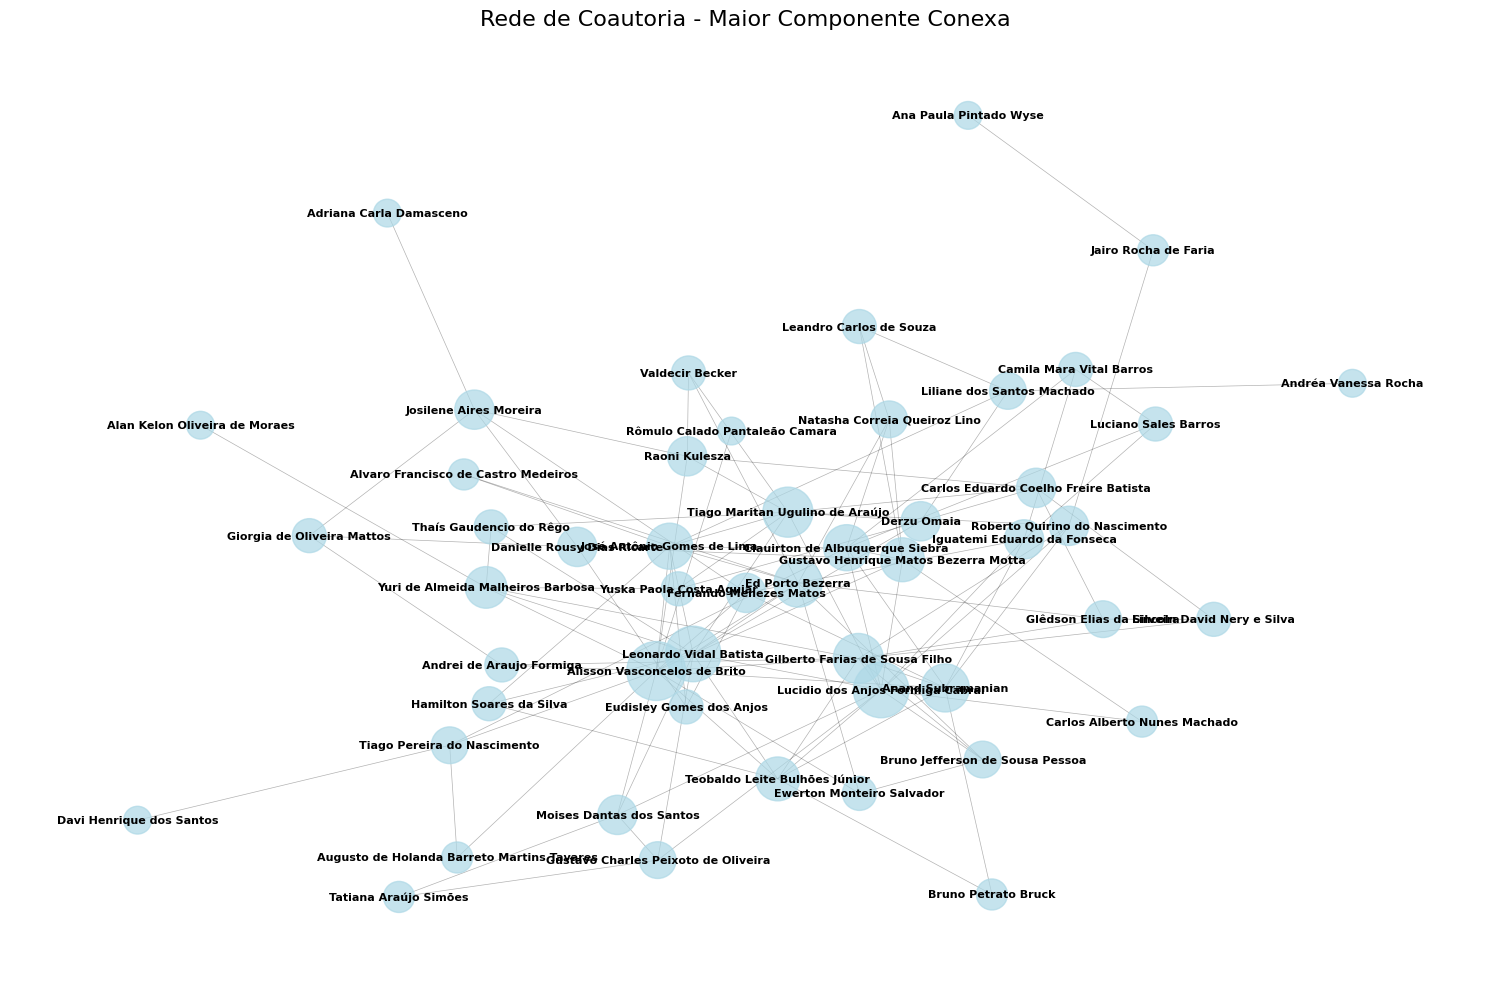


=== TOP 15 PESQUISADORES (MAIOR GRAU) ===
Alisson Vasconcelos de Brito: 15 coautores
Leonardo Vidal Batista: 13 coautores
Lucidio dos Anjos Formiga Cabral: 13 coautores
Gilberto Farias de Sousa Filho: 10 coautores
Tiago Maritan Ugulino de Araújo: 10 coautores
Ed Porto Bezerra: 9 coautores
Anand Subramanian: 9 coautores
José Antônio Gomes de Lima: 8 coautores
Clauirton de Albuquerque Siebra: 8 coautores
Gustavo Henrique Matos Bezerra Motta: 7 coautores
Teobaldo Leite Bulhões Júnior: 7 coautores
Yuri de Almeida Malheiros Barbosa: 6 coautores
Derzu Omaia: 5 coautores
Carlos Eduardo Coelho Freire Batista: 5 coautores
Raoni Kulesza: 5 coautores


In [73]:
# Criar grafo não-direcionado
G = nx.Graph()

# Adicionar arestas com pesos (similaridade)
for _, row in df_arestas.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Similaridade"],
        titulo=row["Titulo"],
        ano=row["Ano"],
    )

# Calcular métricas do grafo
metricas = {
    "num_nos": G.number_of_nodes(),
    "num_arestas": G.number_of_edges(),
    "densidade": nx.density(G),
    "grau_medio": sum(dict(G.degree()).values()) / G.number_of_nodes() # type: ignore
    if G.number_of_nodes() > 0
    else 0,  # type: ignore
}

# Componentes conexas
componentes = list(nx.connected_components(G))
metricas["num_componentes"] = len(componentes)
metricas["tamanho_maior_componente"] = (
    len(max(componentes, key=len)) if componentes else 0
)
metricas["percentagem_maior_componente"] = (
    (metricas["tamanho_maior_componente"] / metricas["num_nos"] * 100)
    if metricas["num_nos"] > 0
    else 0
)

# Maior componente conexa
maior_componente = G.subgraph(max(componentes, key=len)).copy() if componentes else G

# Métricas da maior componente
if maior_componente.number_of_nodes() > 0:
    metricas["diametro"] = (
        nx.diameter(maior_componente)
        if nx.is_connected(maior_componente)
        else "Não conexo"
    )
    metricas["caminho_medio"] = (
        nx.average_shortest_path_length(maior_componente)
        if nx.is_connected(maior_componente)
        else "Não conexo"
    )
    metricas["transitividade"] = nx.transitivity(maior_componente)
    metricas["assortatividade"] = nx.degree_assortativity_coefficient(maior_componente)
    metricas["coeficiente_clustering"] = nx.average_clustering(maior_componente)

# Rich club coefficient (k=percentil 80 do grau)
graus = [d for n, d in G.degree()]  # type: ignore
if graus:
    k_threshold = int(sorted(graus)[int(len(graus) * 0.8)])
    metricas["rich_club_k80"] = nx.rich_club_coefficient(G, normalized=False).get(
        k_threshold, 0
    )

# Exibir métricas
print("=== MÉTRICAS DA REDE DE COAUTORIA ===\n")
for metrica, valor in metricas.items():
    print(f"{metrica}: {valor}")

# Visualizar o grafo (maior componente)
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(maior_componente, k=0.5, iterations=50)

# Calcular tamanhos dos nós (baseado no grau)
node_sizes = [300 + 100 * maior_componente.degree(n) for n in maior_componente.nodes()]  # type: ignore

# Desenhar
nx.draw_networkx_nodes(
    maior_componente, pos, node_size=node_sizes, node_color="lightblue", alpha=0.7
)
nx.draw_networkx_edges(maior_componente, pos, alpha=0.3, width=0.5)
nx.draw_networkx_labels(maior_componente, pos, font_size=8, font_weight="bold")

plt.title("Rede de Coautoria - Maior Componente Conexa", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

# Top 15 pesquisadores por grau (mais coautores)
top_grau = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:15]  # type: ignore
print("\n=== TOP 15 PESQUISADORES (MAIOR GRAU) ===")
for nome, grau in top_grau:
    print(f"{nome}: {grau} coautores")